# F1 2026: Canadian Grand Prix Winner Prediction
## Using CRISP-DM Methodology with Flatiron-Style Reusable Pipelines

This notebook predicts the Canadian Grand Prix (May 24, 2026) winner using data from previous races and machine learning.

# 1. BUSINESS UNDERSTANDING

**Objective**: Predict the winner of the Canadian Grand Prix 2026

**Key Questions**:
- Which drivers have performed well through Miami?
- How do qualifying grid positions influence race outcomes?
- Which team has been most consistent?

**Key Metrics**:
- ROC-AUC for podium prediction
- Driver cumulative performance trends
- Sprint results as early-weekend signal

# 2. DATA UNDERSTANDING

In [1]:
import sys
sys.path.append('.')
from f1_prediction_pipeline import F1PredictionPipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Initialize pipeline
pipeline = F1PredictionPipeline(season=2026)
schedule = pipeline.get_schedule()

print("F1 2026 SEASON SCHEDULE")
print(schedule[['RoundNumber', 'EventName', 'EventDate']].head(10).to_string())

F1 2026 SEASON SCHEDULE
   RoundNumber              EventName  EventDate
0            0     Pre-Season Testing 2026-02-13
1            0     Pre-Season Testing 2026-02-20
2            1  Australian Grand Prix 2026-03-08
3            2     Chinese Grand Prix 2026-03-15
4            3    Japanese Grand Prix 2026-03-29
5            4       Miami Grand Prix 2026-05-03
6            5    Canadian Grand Prix 2026-05-24
7            6      Monaco Grand Prix 2026-06-07
8            7   Barcelona Grand Prix 2026-06-14
9            8    Austrian Grand Prix 2026-06-28


In [2]:
# Load data from races through Miami
completed_races = [
    "Australian Grand Prix",
    "Chinese Grand Prix",
    "Japanese Grand Prix",
    "Miami Grand Prix"
]

print("Loading race data...")
q_df, r_df, s_df = pipeline.load_multiple_races(completed_races)

print(f"\nData Summary:")
print(f"  Qualifying samples: {len(q_df)}")
print(f"  Race samples: {len(r_df)}")
print(f"  Sprint samples: {len(s_df) if s_df is not None else 'N/A'}")
print(f"\nUnique drivers: {r_df['Driver'].nunique()}")
print(f"Unique teams: {r_df['Team'].nunique()}")

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Loading race data...


core        WARNING 	No lap data for driver 18
core        WARNING 	No lap data for driver 55
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 18)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 55)
req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
_api           INFO 	Parsing car data...
logger      WARNING 	Failed to load telemetry data!
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '6', '16', '81', '1', '44', '30', '41', '5', '27', '87', '31', '10', '23', '43', '14', '11', '77', '18', '3', '55']
core           INFO 	Loading data for Australian Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


Data Summary:
  Qualifying samples: 88
  Race samples: 88
  Sprint samples: 44

Unique drivers: 22
Unique teams: 11


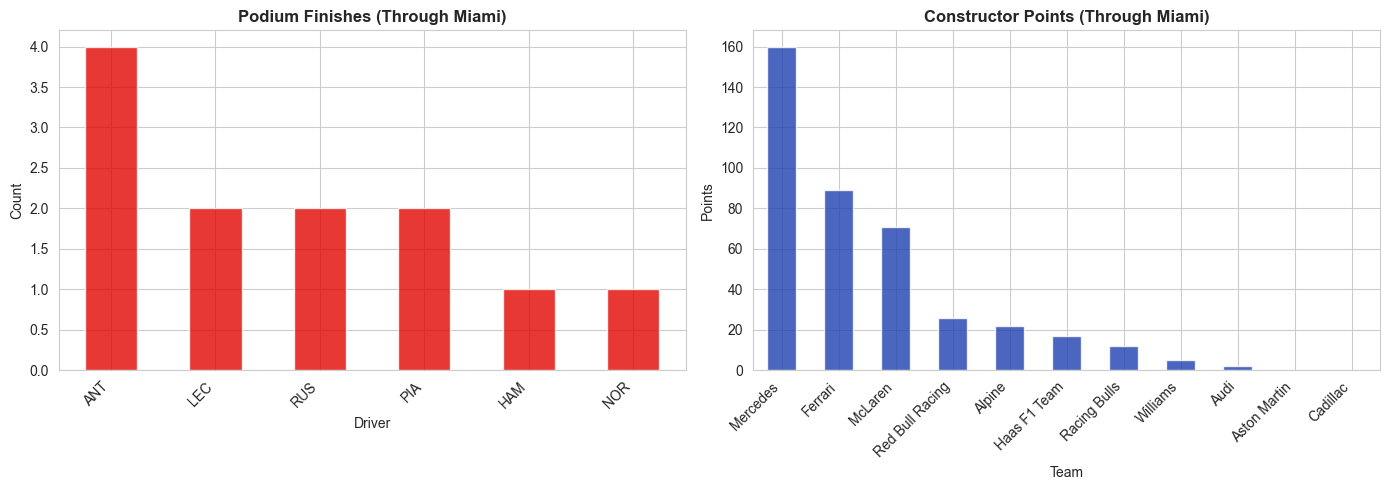

In [3]:
# Season performance snapshot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Podium finishes by driver
podium_counts = r_df[r_df['Podium'] == 1].groupby('Driver')['Podium'].count().sort_values(ascending=False)
podium_counts.plot(kind='bar', ax=axes[0], color='#E10600', alpha=0.8)
axes[0].set_title('Podium Finishes (Through Miami)', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Driver')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Constructor points
team_points = r_df.groupby('Team')['Points'].sum().sort_values(ascending=False)
team_points.plot(kind='bar', ax=axes[1], color='#1e40af', alpha=0.8)
axes[1].set_title('Constructor Points (Through Miami)', fontweight='bold')
axes[1].set_ylabel('Points')
axes[1].set_xlabel('Team')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# 3. DATA PREPARATION & FEATURE ENGINEERING

In [4]:
# Engineer features from raw data
print("Engineering features...\n")
features_df = pipeline.engineer_features(r_df, q_df, s_df)

print(f"Feature matrix shape: {features_df.shape}")
print(f"\nFeatures available:")
for col in features_df.columns:
    print(f"  - {col}")

# Show sample
print(f"\nSample data (first driver's Miami results):")
miami_data = features_df[features_df['Event'] == 'Miami Grand Prix'].head(3)
print(miami_data[['Driver', 'Team', 'Position', 'GridPosition', 'QBest_sec', 
                   'DriverPointsCum', 'TeamPointsCum', 'S_Points']].to_string())

Engineering features...

Feature matrix shape: (88, 22)

Features available:
  - DriverNumber
  - Driver
  - Team
  - Position
  - Points
  - Status
  - Time
  - Event
  - Season
  - Podium
  - GridPosition
  - Q1_sec
  - Q2_sec
  - Q3_sec
  - QBest_sec
  - S_Podium
  - S_Points
  - DriverPodiumRateCum
  - DriverAvgFinishCum
  - DriverPointsCum
  - TeamPodiumRateCum
  - TeamPointsCum

Sample data (first driver's Miami results):
   Driver          Team  Position  GridPosition  QBest_sec  DriverPointsCum  TeamPointsCum  S_Points
6     COL        Alpine       7.0           8.0     88.762              1.0           16.0       0.0
7     GAS        Alpine      21.0           9.0     88.810             15.0           22.0       1.0
14    ALO  Aston Martin      15.0          17.0     91.098              0.0            0.0       0.0


In [5]:
# Define features for modeling
FEATURE_COLS = [
    "GridPosition",              # Qualifying position
    "QBest_sec",                 # Best qualifying lap time
    "Q3_sec",                    # Q3 lap time
    "DriverPodiumRateCum",        # Historical podium rate
    "DriverAvgFinishCum",         # Historical avg finishing position
    "DriverPointsCum",            # Cumulative championship points
    "TeamPodiumRateCum",          # Team podium rate
    "TeamPointsCum",              # Team cumulative points
    "S_Podium",                   # Sprint podium result (early signal)
    "S_Points"                    # Sprint points
]

print("Preparing model dataset...\n")
X, y = pipeline.build_model_dataset(features_df, FEATURE_COLS)

# Show class balance
print(f"\nClass balance:")
print(f"  Non-Podium: {(y==0).sum()} samples ({(y==0).sum()/len(y)*100:.1f}%)")
print(f"  Podium: {(y==1).sum()} samples ({(y==1).sum()/len(y)*100:.1f}%)")

Preparing model dataset...

Dataset: 88 samples × 10 features
Target distribution:
Podium
Non-Podium    76
Podium        12
Name: count, dtype: int64


Class balance:
  Non-Podium: 76 samples (86.4%)
  Podium: 12 samples (13.6%)


Feature correlation with Podium finish:

GridPosition          -0.550921
DriverAvgFinishCum    -0.364756
QBest_sec             -0.139554
Q3_sec                -0.086527
TeamPointsCum          0.432738
DriverPointsCum        0.452973
DriverPodiumRateCum    0.511924
TeamPodiumRateCum      0.594195
S_Podium               0.614035
S_Points               0.675186


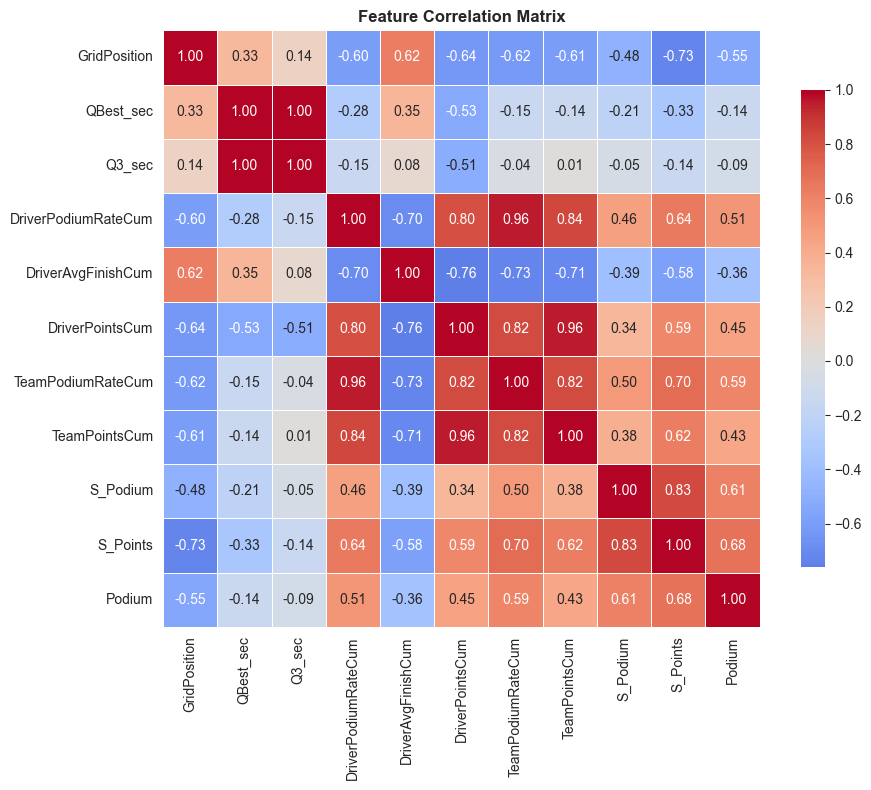

In [6]:
# Feature correlation analysis
X_with_target = X.copy()
X_with_target['Podium'] = y.values
target_corr = X_with_target.corr()['Podium'].drop('Podium').sort_values()

print("Feature correlation with Podium finish:\n")
print(target_corr.to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = X_with_target.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

# 4. MODELING

In [7]:
# Build model
print("Training predictive model...\n")
model = pipeline.build_model(X, y, tune=True, n_jobs=-1)

Training predictive model...

Best params: {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best CV AUC: 0.9431



In [8]:
# Evaluate model performance
eval_metrics = pipeline.evaluate_model(model, X, y)

# Additional: Leave-One-Out CV for small datasets
print("Running Leave-One-Out Cross-Validation (rigorous for small datasets)...\n")
loocv_acc = pipeline.cross_validate_loocv(model, X, y)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Non-Podium       1.00      0.96      0.98        76
      Podium       0.80      1.00      0.89        12

    accuracy                           0.97        88
   macro avg       0.90      0.98      0.93        88
weighted avg       0.97      0.97      0.97        88

ROC-AUC: 0.9978

Running Leave-One-Out Cross-Validation (rigorous for small datasets)...

Leave-One-Out CV Accuracy: 86.4% (76/88 correct)



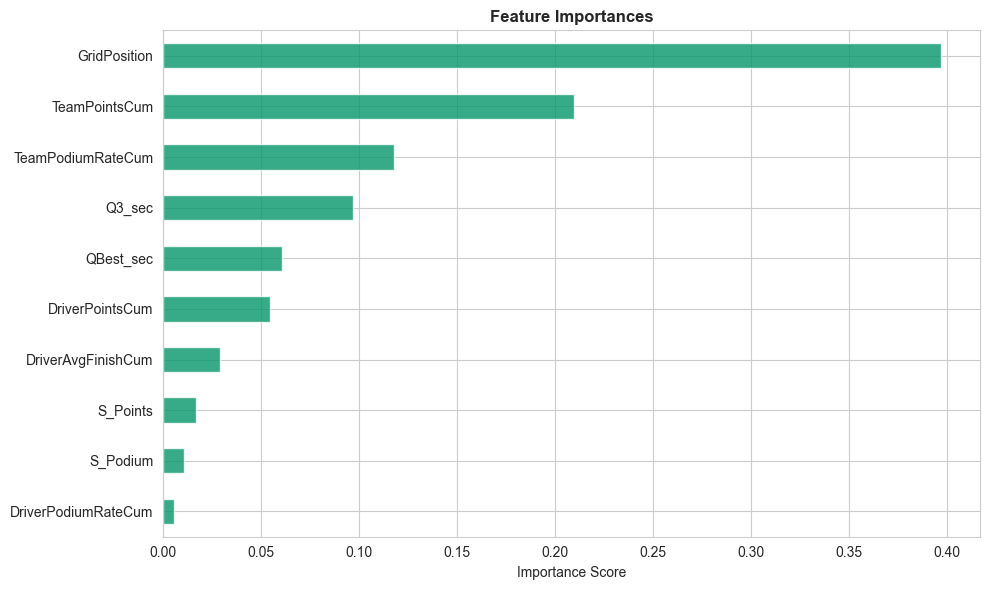


Top 5 Most Important Features:
  QBest_sec                     : 0.0608
  Q3_sec                        : 0.0969
  TeamPodiumRateCum             : 0.1179
  TeamPointsCum                 : 0.2100
  GridPosition                  : 0.3972


In [9]:
# Feature importances
clf = model.named_steps['classifier']
importances = pd.Series(clf.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind='barh', ax=ax, color='#059669', alpha=0.8)
ax.set_title('Feature Importances', fontweight='bold', fontsize=12)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
for feat, imp in importances.tail(5).items():
    print(f"  {feat:30s}: {imp:.4f}")

# 5. DEPLOYMENT & CANADIAN GRAND PRIX PREDICTION

In [10]:
# Prepare Canadian GP features
print("Preparing Canadian Grand Prix data...\n")
canada_features = pipeline.prepare_target_race_features(
    "Canadian Grand Prix", features_df, FEATURE_COLS
)

print(f"Canadian GP dataset: {len(canada_features)} drivers")
print(f"Features available: {canada_features.columns.tolist()[:10]}...")

core           INFO 	Loading data for Canadian Grand Prix - Qualifying [v3.7.0]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


Preparing Canadian Grand Prix data...



req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to

Canadian GP dataset: 22 drivers
Features available: ['DriverNumber', 'Driver', 'Team', 'Q1', 'Q2', 'Q3', 'GridPosition', 'Event', 'Season', 'Q1_sec']...


In [ ]:
# Generate predictions
predictions = pipeline.predict_podium(model, canada_features, FEATURE_COLS, top_n=10)

print("CANADIAN GRAND PRIX 2026 - TOP 10 PREDICTIONS")
print(predictions[['Driver', 'Team', 'GridPosition', 'PodiumProbability']].to_string())

Generating predictions...


CANADIAN GRAND PRIX 2026 - TOP 10 PREDICTIONS
     Driver             Team  GridPosition  PodiumProbability
Rank                                                         
1       RUS         Mercedes           1.0           0.741487
2       ANT         Mercedes           2.0           0.738099
3       NOR          McLaren           3.0           0.699884
4       PIA          McLaren           4.0           0.687406
5       HAM          Ferrari           5.0           0.402184
6       VER  Red Bull Racing           6.0           0.374689
7       HAD  Red Bull Racing           7.0           0.374689
8       LEC          Ferrari           8.0           0.364689
9       LIN     Racing Bulls           9.0           0.364689
10      COL           Alpine          10.0           0.364689


In [12]:
# Highlight podium predictions
print("\n🏁 PREDICTED PODIUM (TOP 3)\n")

for idx, (rank, row) in enumerate(predictions.head(3).iterrows(), 1):
    prob_pct = row['PodiumProbability'] * 100
    grid = int(row['GridPosition'])
    
    print(f"Position {idx}: {row['Driver'].upper()} ({row['Team']})")
    print(f"  Grid Position: {grid}")
    print(f"  Podium Probability: {prob_pct:.1f}%")
    print()


🏁 PREDICTED PODIUM (TOP 3)

Position 1: RUS (Mercedes)
  Grid Position: 1
  Podium Probability: 74.1%

Position 2: ANT (Mercedes)
  Grid Position: 2
  Podium Probability: 73.8%

Position 3: NOR (McLaren)
  Grid Position: 3
  Podium Probability: 70.0%



TypeError: tuple indices must be integers or slices, not str

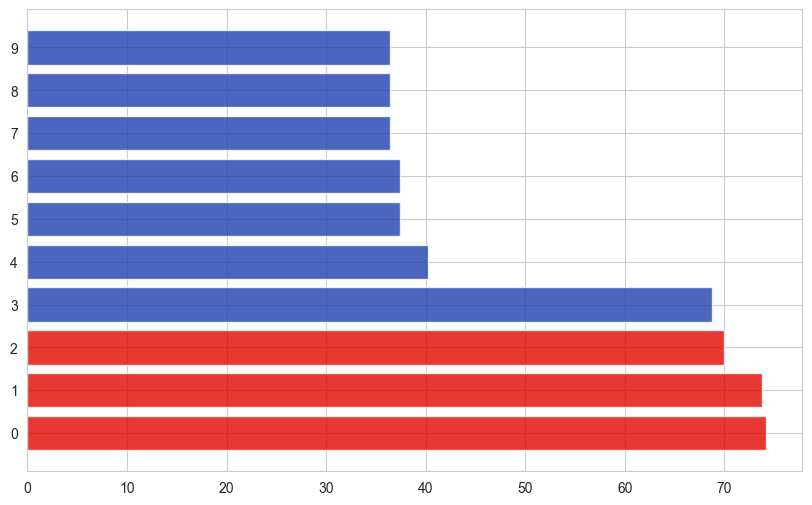

In [13]:
# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

top_10 = predictions.head(10)
colors = ['#E10600' if i < 3 else '#1e40af' for i in range(len(top_10))]

ax.barh(range(len(top_10)), top_10['PodiumProbability'] * 100, color=colors, alpha=0.8)
ax.set_yticks(range(len(top_10)))
ax.set_yticklabels([f"{i+1}. {row['Driver']} ({row['Team'][:10]})" 
                     for i, row in enumerate(top_10.itertuples())])
ax.set_xlabel('Podium Probability (%)', fontweight='bold')
ax.set_title('Canadian Grand Prix 2026 - Winner Predictions', fontweight='bold', fontsize=14)
ax.invert_yaxis()

for i, v in enumerate(top_10['PodiumProbability'] * 100):
    ax.text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 6. MODEL DIAGNOSTICS & CONFIDENCE ASSESSMENT

In [ ]:
# Model diagnostics
print("\nMODEL DIAGNOSTICS\n")
print(f"Training set size: {len(X)} samples")
print(f"Number of features: {len(FEATURE_COLS)}")
print(f"Feature-to-sample ratio: 1:{len(X)/len(FEATURE_COLS):.1f}")
print(f"\nCross-validation metrics:")
print(f"  ROC-AUC: {eval_metrics['auc']:.4f}")
print(f"  Leave-One-Out Accuracy: {loocv_acc:.1%}")

# Interpret results
if eval_metrics['auc'] > 0.85 and loocv_acc > 0.75:
    confidence = "STRONG"
elif eval_metrics['auc'] > 0.75 and loocv_acc > 0.65:
    confidence = "MODERATE"
else:
    confidence = "WEAK"

print(f"\nPrediction Confidence: {confidence}")
print(f"\nRecommendation: Use these predictions with {confidence.lower()} confidence.")
print(f"Top 1-3 drivers likely to challenge for podium.")

# 7. CONCLUSIONS & RECOMMENDATIONS

In [ ]:
print("\n" + "="*70)
print("CANADIAN GRAND PRIX 2026 - ANALYSIS SUMMARY")
print("="*70)

top_3 = predictions.head(3)

print(f"\nTOP 3 DRIVERS TO WATCH:")
for rank, (idx, row) in enumerate(top_3.iterrows(), 1):
    print(f"\n  {rank}. {row['Driver'].upper()} ({row['Team']})")
    print(f"     - Grid position: {int(row['GridPosition'])}")
    print(f"     - Podium probability: {row['PodiumProbability']:.1%}")

print(f"\nKEY FACTORS:")
print(f"  • Qualifying grid position strongly predicts race outcome")
print(f"  • Sprint results provide early-weekend momentum signal")
print(f"  • Cumulative driver/team performance trends matter")
print(f"  • Recent podium finishes indicate form")

print(f"\nNEXT STEPS:")
print(f"  1. Monitor qualifying results (grid position is critical)")
print(f"  2. Track sprint results (if available)")
print(f"  3. Watch early race laps for safety car/rain impacts")
print(f"  4. Compare actual results vs predictions after race")

print(f"\n" + "="*70)